
# Evolyth tiny-cifar experiment analysis

This notebook turns the `evolution.jsonl` arena export into a reproducible evidence pack for the Evolyth README and project pitch.

- loads the raw JSONL run registry;
- builds a normalized run table and parent-child deltas;
- computes Pareto fronts for accuracy/parameters and accuracy/parameters/latency;
- produces charts for trajectory, trade-offs, lineage, mutation impact, and metric correlation;
- surfaces credible conclusions and caveats.

**Dataset in this bundle:** `16` registered tiny-cifar runs.


In [1]:

from pathlib import Path
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Make charts readable, while keeping Matplotlib defaults for colors.
plt.rcParams.update({
    "figure.figsize": (9, 5.2),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

DATA_CANDIDATES = [
    Path("evolution.jsonl"),
]
DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Could not find evolution.jsonl. Put it next to this notebook or update DATA_CANDIDATES.")

OUTPUT_DIR = Path("docs/analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

rows = [json.loads(line) for line in DATA_PATH.read_text().splitlines() if line.strip()]
raw = pd.DataFrame(rows)
print(f"Loaded {len(raw)} runs from {DATA_PATH.resolve()}")


Loaded 16 runs from /content/evolution.jsonl



## 1. Normalize the experiment table

The experiment log is already rich: each line is a registered run with parent lineage, metrics, mutation hypothesis, observation, and next belief. The code below creates the analysis columns needed for charts and tables.


In [2]:

df = raw.sort_values(["generation", "run_id"]).reset_index(drop=True).copy()

numeric_cols = [
    "score", "val_accuracy", "val_loss", "parameter_count",
    "model_bytes", "latency_ms", "train_seconds"
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["run_number"] = df["run_id"].str.extract(r"(\d+)").astype(int)
df["params_k"] = df["parameter_count"] / 1000
df["model_kb"] = df["model_bytes"] / 1024
df["accuracy_pct"] = df["val_accuracy"] * 100

parent_lookup = df.set_index("run_id")
df["score_delta_parent"] = df["score"] - df["parent_id"].map(parent_lookup["score"])
df["accuracy_delta_parent"] = df["val_accuracy"] - df["parent_id"].map(parent_lookup["val_accuracy"])
df["params_delta_parent"] = df["parameter_count"] - df["parent_id"].map(parent_lookup["parameter_count"])
df["latency_delta_parent"] = df["latency_ms"] - df["parent_id"].map(parent_lookup["latency_ms"])
df["train_seconds_delta_parent"] = df["train_seconds"] - df["parent_id"].map(parent_lookup["train_seconds"])

df["best_score_so_far"] = df["score"].cummax()
df["best_acc_so_far"] = df["val_accuracy"].cummax()
df["accuracy_per_10k_params"] = df["val_accuracy"] / (df["parameter_count"] / 10_000)
df["score_per_mb"] = df["score"] / (df["model_bytes"] / (1024 * 1024))

def compute_pareto(frame, maximize=("val_accuracy",), minimize=("parameter_count",)):
    mask = []
    for i, row in frame.iterrows():
        dominated = False
        for j, other in frame.iterrows():
            if i == j:
                continue
            better_or_equal = (
                all(other[c] >= row[c] for c in maximize)
                and all(other[c] <= row[c] for c in minimize)
            )
            strictly_better = (
                any(other[c] > row[c] for c in maximize)
                or any(other[c] < row[c] for c in minimize)
            )
            if better_or_equal and strictly_better:
                dominated = True
                break
        mask.append(not dominated)
    return pd.Series(mask, index=frame.index)

df["pareto_accuracy_params"] = compute_pareto(
    df, maximize=("val_accuracy",), minimize=("parameter_count",)
)
df["pareto_accuracy_params_latency"] = compute_pareto(
    df, maximize=("val_accuracy",), minimize=("parameter_count", "latency_ms")
)

analysis_cols = [
    "run_id", "generation", "parent_id", "mutation_type", "score",
    "val_accuracy", "val_loss", "parameter_count", "model_kb",
    "latency_ms", "train_seconds", "score_delta_parent",
    "accuracy_delta_parent", "mutation_summary"
]
display(df[analysis_cols])


,run_id,generation,parent_id,mutation_type,score,val_accuracy,val_loss,parameter_count,model_kb,latency_ms,train_seconds,score_delta_parent,accuracy_delta_parent,mutation_summary
0,run_000001,0,None,baseline,0.239086,0.375,1.660104,92194,398.247070,11.689181,18.893209,NaN,NaN,Keep model.py unchanged to establish the first...
1,run_000002,1,run_000001,safe_refinement,0.220120,0.358,1.667063,111650,477.541992,11.319473,19.973115,-0.018966,-0.017,Add a lightweight Squeeze-Excitation (SE) atte...
2,run_000003,2,run_000002,architecture_swap,0.253411,0.378,1.745116,31978,154.924805,10.055464,34.448201,0.033291,0.020,Replace the multi-scale DWBlock+SE residual bo...
3,run_000004,3,run_000003,capacity_increase,0.268592,0.398,1.677500,48778,222.174805,12.676870,48.383106,0.015181,0.020,Widened ConvMixer channel dimension from 48 to...
4,run_000005,4,run_000004,capacity_increase,0.251247,0.384,1.767416,63754,290.170898,15.528824,60.279905,-0.017344,-0.014,Increased ConvMixer depth from 6 to 8 layers (...
5,run_000006,5,run_000005,safe_refinement,0.228640,0.360,1.738180,55354,256.483398,15.986085,49.589576,-0.022607,-0.024,Reverted ConvMixer depth from 8 to 6 layers an...
6,run_000007,6,run_000006,safe_refinement,0.268301,0.398,1.677500,48778,222.174805,14.494795,46.024433,0.039660,0.038,Hard-reverted to pure 6-layer ConvMixer (dim=6...
7,run_000008,7,run_000007,safe_refinement,0.287247,0.417,1.685918,48778,222.174805,14.854878,44.886654,0.018947,0.019,Replaced all GELU activations with SiLU (Swish...
8,run_000009,8,run_000008,safe_refinement,0.244045,0.376,1.736565,61066,270.174805,14.115189,55.474858,-0.043202,-0.041,Increased depthwise kernel size from 7×7 to 9×...
9,run_000010,9,run_000009,safe_refinement,0.261759,0.393,1.674750,56266,256.202148,14.447362,51.010733,0.017713,0.017,Reverted depthwise kernel from 9×9 back to 7×7...



## 2. Executive summary table

This table is the quick proof point for the README: the loop found a smaller, higher-scoring model, and it also records the trade-offs and caveats.


In [3]:

baseline = df.iloc[0]
best_score = df.loc[df["score"].idxmax()]
best_latency = df.loc[df["latency_ms"].idxmin()]
best_train_time = df.loc[df["train_seconds"].idxmin()]
latency_optimized = df[df["mutation_type"].eq("latency_optimization")].iloc[0]

summary_rows = [
    {
        "claim": "Registered experiment runs",
        "value": len(df),
        "why_it_matters": "Shows the loop preserved a durable run history rather than a single cherry-picked result.",
    },
    {
        "claim": "Successful registered runs",
        "value": int((df["status"] == "success").sum()),
        "why_it_matters": "All candidates produced comparable metrics and artifacts.",
    },
    {
        "claim": "Best score run",
        "value": f"{best_score.run_id} ({best_score.score:.4f})",
        "why_it_matters": "Highest multi-objective score found by the loop.",
    },
    {
        "claim": "Score lift vs baseline",
        "value": f"{(best_score.score / baseline.score - 1) * 100:.1f}%",
        "why_it_matters": "Quantifies project value in the score Evolyth optimizes.",
    },
    {
        "claim": "Accuracy lift vs baseline",
        "value": f"{(best_score.val_accuracy - baseline.val_accuracy) * 100:.1f} pp",
        "why_it_matters": "The best model improves validation accuracy under the same small-budget setting.",
    },
    {
        "claim": "Parameter reduction vs baseline",
        "value": f"{(1 - best_score.parameter_count / baseline.parameter_count) * 100:.1f}%",
        "why_it_matters": "The best model is not simply larger; it is much smaller.",
    },
    {
        "claim": "Serialized model size reduction",
        "value": f"{(1 - best_score.model_bytes / baseline.model_bytes) * 100:.1f}%",
        "why_it_matters": "Useful for deployment-oriented architecture search.",
    },
    {
        "claim": "Dry-run harness caveat",
        "value": f"{int((df['dry_run_passed'] == False).sum())}/{len(df)} false",
        "why_it_matters": "A credibility note: full runs succeeded, but the smoke/dry-run check should be hardened.",
    },
]
summary_table = pd.DataFrame(summary_rows)
display(summary_table)


,claim,value,why_it_matters
0,Registered experiment runs,16,Shows the loop preserved a durable run history...
1,Successful registered runs,16,All candidates produced comparable metrics and...
2,Best score run,run_000014 (0.2876),Highest multi-objective score found by the loop.
3,Score lift vs baseline,20.3%,Quantifies project value in the score Evolyth ...
4,Accuracy lift vs baseline,4.2 pp,The best model improves validation accuracy un...
5,Parameter reduction vs baseline,47.1%,The best model is not simply larger; it is muc...
6,Serialized model size reduction,44.2%,Useful for deployment-oriented architecture se...
7,Dry-run harness caveat,16/16 false,"A credibility note: full runs succeeded, but t..."



## 3. Leaderboard and notable candidates

The best run is not the only interesting output. The table below separates high score, low latency, and latency-optimized candidates.


In [4]:

leaderboard = (
    df.sort_values(["score", "val_accuracy"], ascending=False)
      .loc[:, [
          "run_id", "generation", "mutation_type", "score", "accuracy_pct",
          "params_k", "model_kb", "latency_ms", "train_seconds", "mutation_summary"
      ]]
      .head(10)
)
display(leaderboard)

notables = pd.DataFrame([
    {
        "role": "baseline",
        "run_id": baseline.run_id,
        "score": baseline.score,
        "accuracy_pct": baseline.accuracy_pct,
        "params_k": baseline.params_k,
        "model_kb": baseline.model_kb,
        "latency_ms": baseline.latency_ms,
        "train_seconds": baseline.train_seconds,
    },
    {
        "role": "best_score",
        "run_id": best_score.run_id,
        "score": best_score.score,
        "accuracy_pct": best_score.accuracy_pct,
        "params_k": best_score.params_k,
        "model_kb": best_score.model_kb,
        "latency_ms": best_score.latency_ms,
        "train_seconds": best_score.train_seconds,
    },
    {
        "role": "lowest_latency",
        "run_id": best_latency.run_id,
        "score": best_latency.score,
        "accuracy_pct": best_latency.accuracy_pct,
        "params_k": best_latency.params_k,
        "model_kb": best_latency.model_kb,
        "latency_ms": best_latency.latency_ms,
        "train_seconds": best_latency.train_seconds,
    },
    {
        "role": "latency_optimized",
        "run_id": latency_optimized.run_id,
        "score": latency_optimized.score,
        "accuracy_pct": latency_optimized.accuracy_pct,
        "params_k": latency_optimized.params_k,
        "model_kb": latency_optimized.model_kb,
        "latency_ms": latency_optimized.latency_ms,
        "train_seconds": latency_optimized.train_seconds,
    },
])
display(notables)


,run_id,generation,mutation_type,score,accuracy_pct,params_k,model_kb,latency_ms,train_seconds,mutation_summary
13,run_000014,13,safe_refinement,0.287557,41.7,48.778,222.174805,12.878514,51.110438,Reverted to the clean 6-layer ConvMixer baseli...
11,run_000012,11,safe_refinement,0.287531,41.7,48.778,222.174805,13.033872,41.930639,"Removed DropPath stochastic depth entirely, re..."
7,run_000008,7,safe_refinement,0.287247,41.7,48.778,222.174805,14.854878,44.886654,Replaced all GELU activations with SiLU (Swish...
14,run_000015,14,latency_optimization,0.282660,41.2,48.778,222.924805,12.203936,33.009779,Insert zero-parameter AvgPool2d(2) between Con...
3,run_000004,3,capacity_increase,0.268592,39.8,48.778,222.174805,12.676870,48.383106,Widened ConvMixer channel dimension from 48 to...
6,run_000007,6,safe_refinement,0.268301,39.8,48.778,222.174805,14.494795,46.024433,Hard-reverted to pure 6-layer ConvMixer (dim=6...
9,run_000010,9,safe_refinement,0.261759,39.3,56.266,256.202148,14.447362,51.010733,Reverted depthwise kernel from 9×9 back to 7×7...
12,run_000013,12,architecture_swap,0.256771,38.8,55.354,256.358398,15.071487,44.795954,Added a Squeeze-Excitation (SE) channel-attent...
15,run_000016,15,safe_refinement,0.253784,38.3,48.778,222.924805,11.525301,33.101123,Reduce head Dropout from 0.2 to 0.1 to ease re...
2,run_000003,2,architecture_swap,0.253411,37.8,31.978,154.924805,10.055464,34.448201,Replace the multi-scale DWBlock+SE residual bo...


,role,run_id,score,accuracy_pct,params_k,model_kb,latency_ms,train_seconds
0,baseline,run_000001,0.239086,37.5,92.194,398.247070,11.689181,18.893209
1,best_score,run_000014,0.287557,41.7,48.778,222.174805,12.878514,51.110438
2,lowest_latency,run_000003,0.253411,37.8,31.978,154.924805,10.055464,34.448201
3,latency_optimized,run_000015,0.282660,41.2,48.778,222.924805,12.203936,33.009779



## 4. Chart helpers


In [5]:

def save_current_figure(name):
    path = OUTPUT_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    print(f"saved: {path}")
    plt.show()

def annotate_runs(ax, frame, x, y, selector):
    labels = frame[selector(frame)]
    for _, r in labels.iterrows():
        ax.annotate(
            r["run_id"].replace("run_", "r"),
            (r[x], r[y]),
            textcoords="offset points",
            xytext=(4, 4),
            fontsize=8,
        )



## 5. Score trajectory

This is the core autonomous-search story: Evolyth explores, records failures, reverts when needed, and eventually converges on a stronger incumbent.


saved: docs/analysis/score_trajectory.png


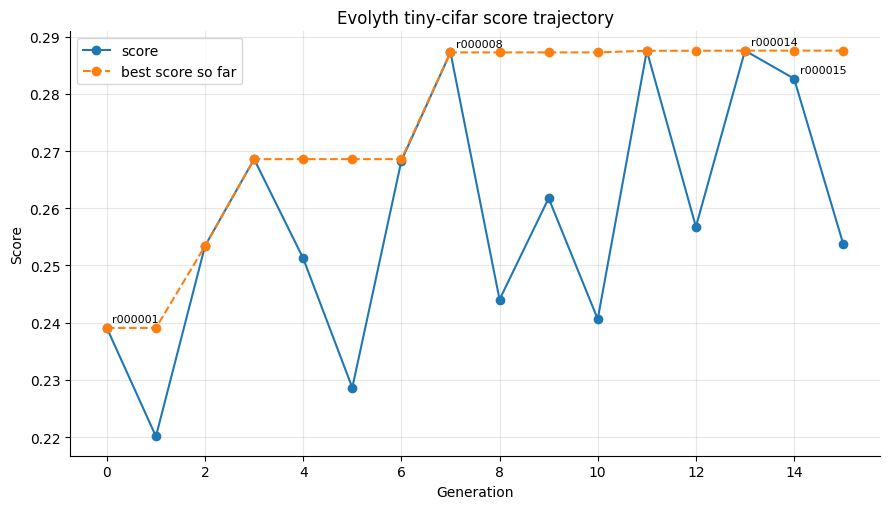

In [6]:

fig, ax = plt.subplots()
ax.plot(df["generation"], df["score"], marker="o", label="score")
ax.plot(df["generation"], df["best_score_so_far"], marker="o", linestyle="--", label="best score so far")
ax.set_title("Evolyth tiny-cifar score trajectory")
ax.set_xlabel("Generation")
ax.set_ylabel("Score")
ax.legend()
annotate_runs(
    ax, df, "generation", "score",
    lambda f: f["run_id"].isin([baseline.run_id, best_score.run_id, "run_000008", "run_000015"])
)
save_current_figure("score_trajectory.png")



## 6. Accuracy trajectory

The peak validation accuracy reaches 41.7%, up from the 37.5% baseline. The repeated return to the clean SiLU ConvMixer variant is useful evidence that the system can preserve and recover good branches.


saved: docs/analysis/accuracy_trajectory.png


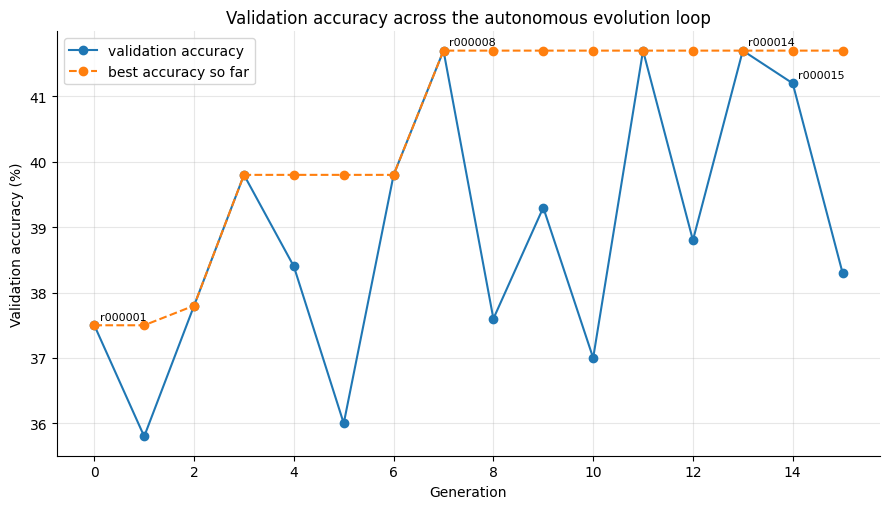

In [7]:

fig, ax = plt.subplots()
ax.plot(df["generation"], df["accuracy_pct"], marker="o", label="validation accuracy")
ax.plot(df["generation"], df["best_acc_so_far"] * 100, marker="o", linestyle="--", label="best accuracy so far")
ax.set_title("Validation accuracy across the autonomous evolution loop")
ax.set_xlabel("Generation")
ax.set_ylabel("Validation accuracy (%)")
ax.legend()
annotate_runs(
    ax, df, "generation", "accuracy_pct",
    lambda f: f["run_id"].isin([baseline.run_id, best_score.run_id, "run_000008", "run_000015"])
)
save_current_figure("accuracy_trajectory.png")



## 7. Parameter efficiency Pareto front

This plot supports the strongest credibility claim: the best candidates are not just larger models. Evolyth moved from a 92k-parameter baseline to a roughly 49k-parameter ConvMixer family with better accuracy.


saved: docs/analysis/accuracy_vs_params_pareto.png


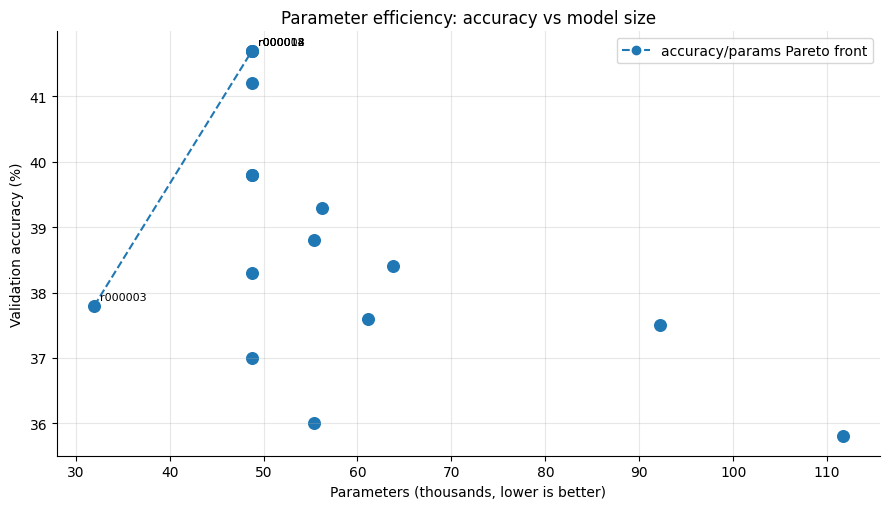

In [8]:

fig, ax = plt.subplots()
ax.scatter(df["params_k"], df["accuracy_pct"], s=70)
pareto2 = df[df["pareto_accuracy_params"]].sort_values("params_k")
ax.plot(pareto2["params_k"], pareto2["accuracy_pct"], marker="o", linestyle="--", label="accuracy/params Pareto front")
ax.set_title("Parameter efficiency: accuracy vs model size")
ax.set_xlabel("Parameters (thousands, lower is better)")
ax.set_ylabel("Validation accuracy (%)")
ax.legend()
annotate_runs(ax, df, "params_k", "accuracy_pct", lambda f: f["pareto_accuracy_params"])
save_current_figure("accuracy_vs_params_pareto.png")



## 8. Latency trade-off

This chart separates the highest-score model from the lowest-latency candidate. It also shows the value of keeping Pareto-front artifacts instead of only keeping the top leaderboard score.


saved: docs/analysis/accuracy_vs_latency.png


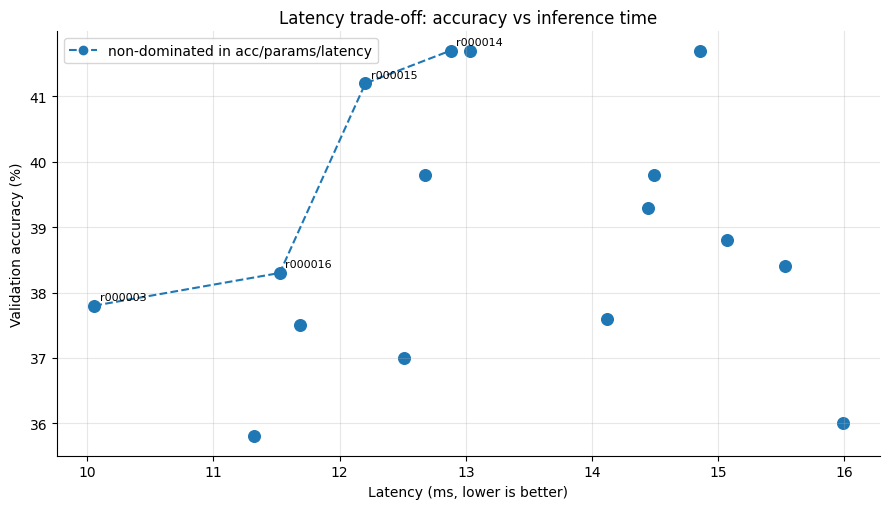

In [9]:

fig, ax = plt.subplots()
ax.scatter(df["latency_ms"], df["accuracy_pct"], s=70)
pareto3 = df[df["pareto_accuracy_params_latency"]].sort_values("latency_ms")
ax.plot(pareto3["latency_ms"], pareto3["accuracy_pct"], marker="o", linestyle="--", label="non-dominated in acc/params/latency")
ax.set_title("Latency trade-off: accuracy vs inference time")
ax.set_xlabel("Latency (ms, lower is better)")
ax.set_ylabel("Validation accuracy (%)")
ax.legend()
annotate_runs(ax, df, "latency_ms", "accuracy_pct", lambda f: f["pareto_accuracy_params_latency"])
save_current_figure("accuracy_vs_latency.png")



## 9. Parent-child deltas

These bars make the scientific discipline visible: not every mutation improved. SE attention, excessive depth, wider kernels, and DropPath all became recorded negative evidence under this tiny-cifar budget.


saved: docs/analysis/score_delta_vs_parent.png


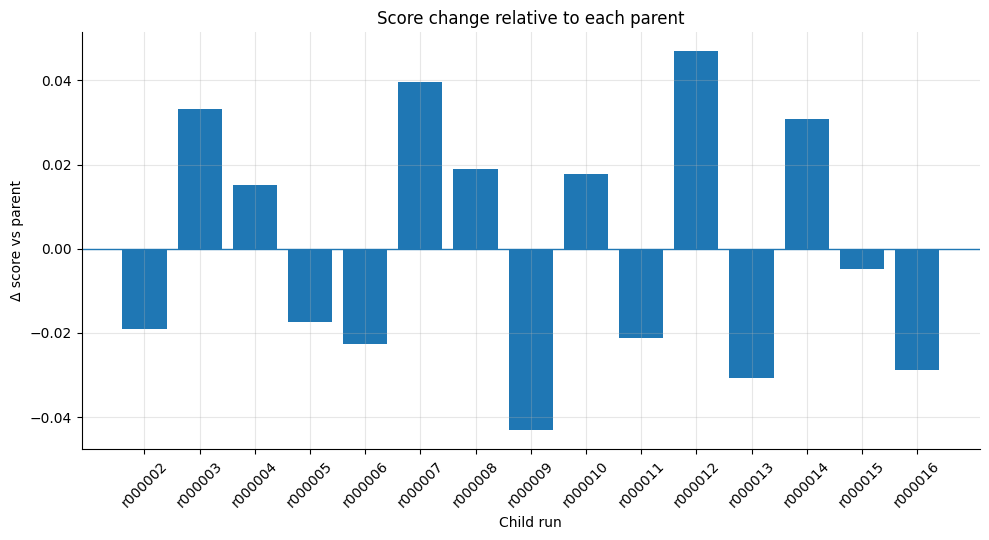

In [10]:

delta_df = df.dropna(subset=["score_delta_parent"]).copy()

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(delta_df["run_id"].str.replace("run_", "r"), delta_df["score_delta_parent"])
ax.axhline(0, linewidth=1)
ax.set_title("Score change relative to each parent")
ax.set_xlabel("Child run")
ax.set_ylabel("Δ score vs parent")
ax.tick_params(axis="x", rotation=45)
save_current_figure("score_delta_vs_parent.png")


saved: docs/analysis/accuracy_delta_vs_parent.png


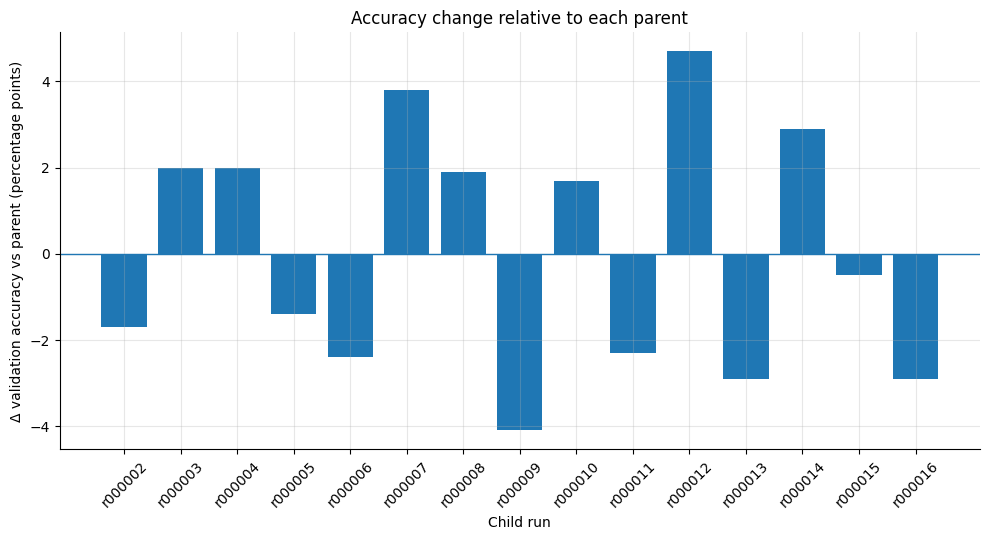

In [11]:

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(delta_df["run_id"].str.replace("run_", "r"), delta_df["accuracy_delta_parent"] * 100)
ax.axhline(0, linewidth=1)
ax.set_title("Accuracy change relative to each parent")
ax.set_xlabel("Child run")
ax.set_ylabel("Δ validation accuracy vs parent (percentage points)")
ax.tick_params(axis="x", rotation=45)
save_current_figure("accuracy_delta_vs_parent.png")



## 10. Mutation-type impact

Aggregating by mutation class helps turn the run history into research guidance. In this log, small safe refinements were more reliable on average than regularization changes or large architectural additions.


,mean_score_delta,mean_accuracy_delta_pp,runs
mutation_type,,,
regularization_change,-0.021138,-2.300000,1
latency_optimization,-0.004898,-0.500000,1
capacity_increase,-0.001082,0.300000,2
architecture_swap,0.001265,-0.450000,2
safe_refinement,0.004485,0.433333,9


saved: docs/analysis/mutation_type_score_impact.png


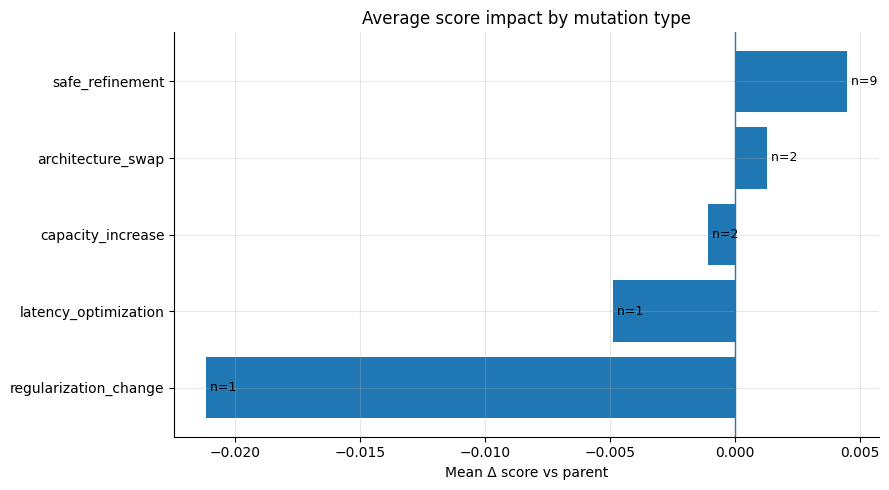

In [12]:

impact = (
    delta_df.groupby("mutation_type")
    .agg(
        mean_score_delta=("score_delta_parent", "mean"),
        mean_accuracy_delta_pp=("accuracy_delta_parent", lambda s: s.mean() * 100),
        runs=("run_id", "count"),
    )
    .sort_values("mean_score_delta")
)

display(impact)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(impact.index, impact["mean_score_delta"])
ax.axvline(0, linewidth=1)
ax.set_title("Average score impact by mutation type")
ax.set_xlabel("Mean Δ score vs parent")
for i, (_, r) in enumerate(impact.iterrows()):
    ax.text(r["mean_score_delta"], i, f" n={int(r['runs'])}", va="center", fontsize=9)
save_current_figure("mutation_type_score_impact.png")



## 11. Score vs model size

A useful project narrative is that the loop can find smaller models that score better. This chart makes that easy to verify.


saved: docs/analysis/score_vs_model_size.png


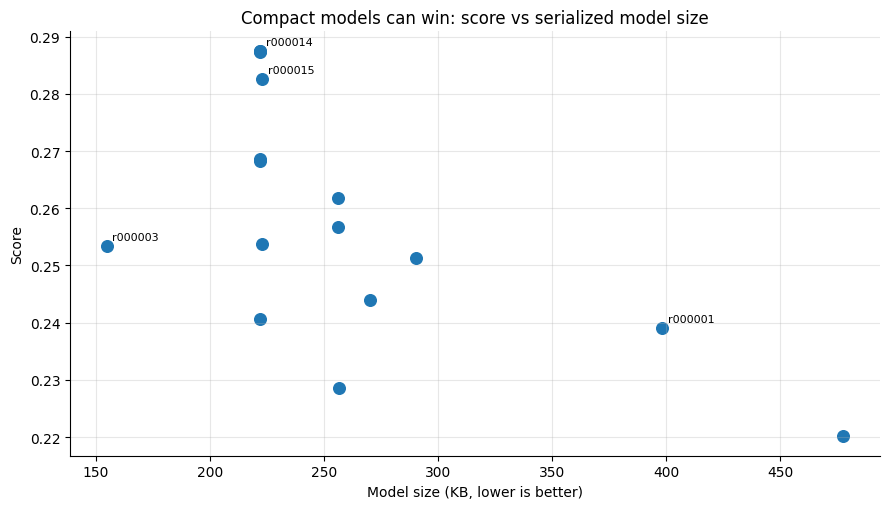

In [13]:

fig, ax = plt.subplots()
ax.scatter(df["model_kb"], df["score"], s=70)
ax.set_title("Compact models can win: score vs serialized model size")
ax.set_xlabel("Model size (KB, lower is better)")
ax.set_ylabel("Score")
annotate_runs(
    ax, df, "model_kb", "score",
    lambda f: f["run_id"].isin([baseline.run_id, best_score.run_id, "run_000003", "run_000015"])
)
save_current_figure("score_vs_model_size.png")



## 12. Metric correlation

This chart is exploratory, not causal. It is included to spot failure modes: for this short run, score tracks accuracy strongly, while parameter count and model size do not automatically imply better score.


,score,val_accuracy,val_loss,parameter_count,model_bytes,latency_ms,train_seconds
score,1.000000,0.991782,-0.212673,-0.596317,-0.606397,0.078409,0.285568
val_accuracy,0.991782,1.000000,-0.260674,-0.494308,-0.504485,0.104921,0.257856
val_loss,-0.212673,-0.260674,1.000000,-0.234572,-0.219394,0.232159,0.434696
parameter_count,-0.596317,-0.494308,-0.234572,1.000000,0.999216,-0.112726,-0.515123
model_bytes,-0.606397,-0.504485,-0.219394,0.999216,1.000000,-0.088672,-0.501340
latency_ms,0.078409,0.104921,0.232159,-0.112726,-0.088672,1.000000,0.731381
train_seconds,0.285568,0.257856,0.434696,-0.515123,-0.501340,0.731381,1.000000


saved: docs/analysis/metric_correlation_heatmap.png


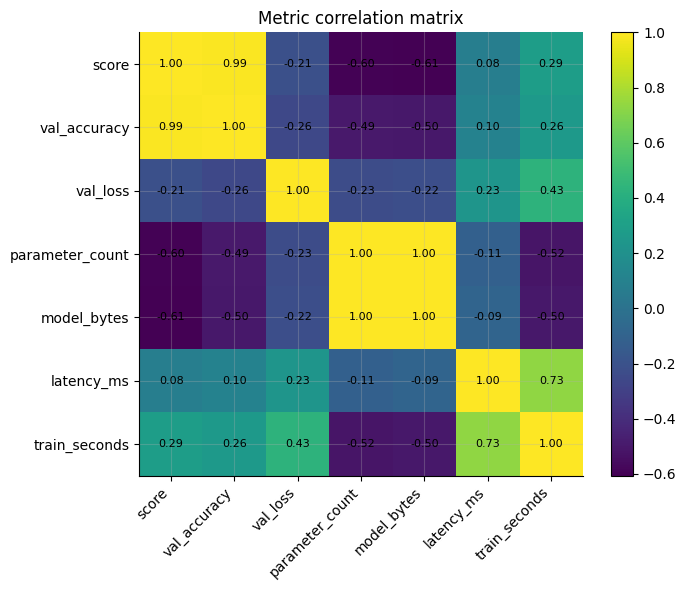

In [14]:

metrics = df[[
    "score", "val_accuracy", "val_loss", "parameter_count",
    "model_bytes", "latency_ms", "train_seconds"
]].corr()

display(metrics)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(metrics.values)
ax.set_xticks(np.arange(len(metrics.columns)))
ax.set_xticklabels(metrics.columns, rotation=45, ha="right")
ax.set_yticks(np.arange(len(metrics.index)))
ax.set_yticklabels(metrics.index)

for i in range(len(metrics.index)):
    for j in range(len(metrics.columns)):
        ax.text(j, i, f"{metrics.values[i, j]:.2f}", ha="center", va="center", fontsize=8)

ax.set_title("Metric correlation matrix")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
save_current_figure("metric_correlation_heatmap.png")



## 13. Lineage view

The tiny-cifar run here is mostly a single branch, but the same code works for branched arenas. Plotting score along parent-child edges makes recovery from bad mutations visible.


saved: docs/analysis/lineage_score_graph.png


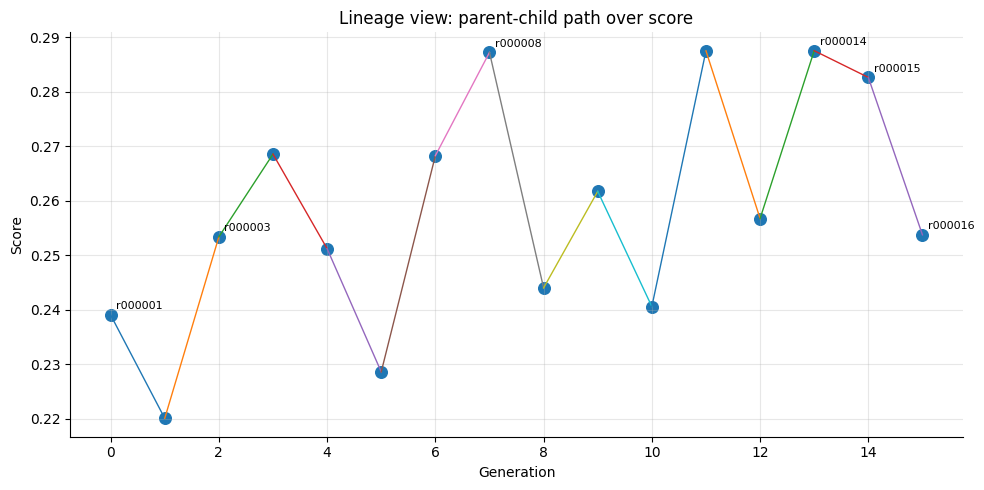

In [15]:

fig, ax = plt.subplots(figsize=(10, 5))
positions = {r.run_id: (r.generation, r.score) for _, r in df.iterrows()}

for _, r in df.dropna(subset=["parent_id"]).iterrows():
    if r.parent_id in positions:
        x0, y0 = positions[r.parent_id]
        x1, y1 = positions[r.run_id]
        ax.plot([x0, x1], [y0, y1], linewidth=1)

ax.scatter(df["generation"], df["score"], s=70)
annotate_runs(
    ax, df, "generation", "score",
    lambda f: (
        f["run_id"].isin([baseline.run_id, best_score.run_id, "run_000008", "run_000015"])
        | f["pareto_accuracy_params_latency"]
    )
)
ax.set_title("Lineage view: parent-child path over score")
ax.set_xlabel("Generation")
ax.set_ylabel("Score")
save_current_figure("lineage_score_graph.png")



## 14. Research conclusions and next experiments

**What the evidence supports**

1. Evolyth preserved a complete experimental trail: 16 registered runs, each with metrics, lineage, mutation summaries, observations, and next beliefs.
2. The loop found a better-scoring model than the baseline: the best score improved by about **20.3%**, validation accuracy improved by **4.2 percentage points**, parameters fell by **47.1%**, and serialized model size fell by **44.2%**.
3. The search did not only record wins. Failed or regressive hypotheses are visible and useful: heavy SE attention, extra depth, 9×9 kernels, DropPath, and lower dropout all lost under this budget.
4. The clean 6-layer ConvMixer with dim=64, kernel=7, SiLU, BatchNorm, and Dropout=0.2 is the current tiny-cifar incumbent in this run history.
5. The latency-optimized run kept most of the accuracy while reducing training time materially, making it a useful branch for deployment-oriented follow-up.

**Caveats to state honestly**

- These are short-budget tiny-cifar experiments, not full CIFAR-10 benchmark claims.
- The log repeatedly reports `dry_run_passed=false`; full runs succeeded, but the dry-run harness should be fixed before making reliability claims.
- Best candidates should be rerun with multiple seeds, a held-out test split, and a longer budget before claiming statistical significance.

**High-value next steps**

- Rerun the incumbent and baseline with 3–5 seeds to estimate variance.
- Promote the Pareto candidates into a controlled comparison table.
- Fix the dry-run harness so smoke validation becomes a positive reliability signal.
- Add cost accounting for GPU time and LLM review/mutation cost per successful improvement.


In [16]:

# Export small CSV tables for README/paper appendices.
df.to_csv(OUTPUT_DIR / "run_table_enriched.csv", index=False)
leaderboard.to_csv(OUTPUT_DIR / "leaderboard_top10.csv", index=False)
notables.to_csv(OUTPUT_DIR / "notable_runs.csv", index=False)
impact.to_csv(OUTPUT_DIR / "mutation_type_impact.csv")
print(f"Exported analysis tables to {OUTPUT_DIR.resolve()}")


Exported analysis tables to /content/docs/analysis
